This is a great step up. Since you're a Data Science Team Lead, we should move away from the "toy" 2D datasets and tackle something high-dimensional where the business value isn't just a plot, but an actionable strategy.

For this challenge, we will use the Credit Card Dataset for Clustering from Kaggle. It has 18 features (balance, purchases, credit limit, etc.) for about 9,000 customers. This is much more challenging because K-Means struggles with high-dimensional "spheres," and DBSCAN (Density-Based Spatial Clustering) will likely flag many customers as "noise" (outliers), which is actually very useful for identifying unique credit behaviors.

The Dataset
Data Link: Credit Card Dataset for Clustering (Kaggle)

The Goal: Define distinct "Customer Personas" for a marketing strategy and identify "anomalous" spenders.

The Challenge: Hybrid Strategy
In this project, you will implement both algorithms to see where they disagree.



Phase 1: Advanced Preprocessing
Imputation: Handle the MINIMUM_PAYMENTS missing values (try a median strategy or a KNN Imputer).

Dimensionality Reduction: Use PCA to reduce the 18 features to a manageable number (capturing 80-90% variance) before feeding it into DBSCAN.

Scaling: Standardize the data so Balance ($10k+) doesn't drown out Purchases_Frequency (0 to 1).

Phase 2: The Code Implementation
This script focuses on the "K-Distance Graph" to find the optimal Epsilon for DBSCAN—a crucial skill for this algorithm.


Phase 3: The "Lead" Analysis Tasks
The Noise Analysis: In your DBSCAN results, check Cluster == -1. These are your outliers. Are they "whales" (ultra-high spenders) or "ghosts" (inactive accounts)?

Centroid Drift: Compare the center of a K-Means cluster to the core points of a DBSCAN cluster. Do they represent the same "type" of customer?

Feature Importance: Use a Random Forest Classifier after clustering, using the Cluster Labels as your y target. This will tell you which features (e.g., CASH_ADVANCE vs PURCHASES) are actually driving the segmentation.


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

Path to dataset files: /Users/rafael/.cache/kagglehub/datasets/arjunbhasin2013/ccdata/versions/1


In [18]:

# 1. Load Data (Assumes you've downloaded CC GENERAL.csv)
df = pd.read_csv(path + '/CC GENERAL.csv').drop('CUST_ID', axis=1)


In [19]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA LOADING & ADVANCED PREPROCESSING
# ==========================================
def load_and_preprocess_data(filepath):
    print("Loading data...")
    df_raw = pd.read_csv(path + '/CC GENERAL.csv')
    
    # Save IDs for later, drop from math operations
    cust_ids = df_raw['CUST_ID']
    # df = df_raw.drop('CUST_ID', axis=1)
    
    # KNN Imputation (Much better than mean/median for clustering)
    # Uses the nearest 5 neighbors to guess missing MINIMUM_PAYMENTS and CREDIT_LIMIT
    print("Imputing missing values using KNN...")
    imputer = KNNImputer(n_neighbors=5)
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    
    # Scaling (Crucial for distance-based algorithms)
    print("Scaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_imputed)
    
    return df_imputed, X_scaled, cust_ids

# ==========================================
# 2. DIMENSIONALITY REDUCTION (PCA)
# ==========================================
def apply_pca(X_scaled, variance_target=0.9):
    print(f"Applying PCA to retain {variance_target*100}% variance...")
    pca = PCA(n_components=variance_target, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"Reduced from {X_scaled.shape[1]} to {X_pca.shape[1]} features.")
    return X_pca, pca

# ==========================================
# 3. K-MEANS OPTIMIZATION & FITTING
# ==========================================
def optimize_and_fit_kmeans(X_pca, df_imputed, max_k=10):
    print("\n--- Running K-Means ---")
    # In a fully automated pipeline, we use Silhouette to pick K dynamically
    best_k = 5
    best_score = -1
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)
        if score > best_score:
            best_score = score
            best_k = k
            
    print(f"Optimal K found: {best_k} (Silhouette: {best_score:.3f})")
    best_k = 3
    # Fit final model
    final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
    df_imputed['Cluster_KMeans'] = final_kmeans.fit_predict(X_pca)
    
    return best_k

# ==========================================
# 4. DBSCAN OPTIMIZATION & FITTING
# ==========================================
def optimize_and_fit_dbscan(X_pca, df_imputed):
    print("\n--- Running DBSCAN ---")
    # Mathematical approach to finding EPS: K-Distance Graph
    # Rule of thumb for min_samples is 2 * dimensions
    min_samples = 2 * X_pca.shape[1] 
    
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_pca)
    distances, _ = neighbors_fit.kneighbors(X_pca)
    distances = np.sort(distances[:, -1], axis=0)
    
    # Approximating the "knee" mathematically (simplified)
    # We look for the point of maximum curvature (highest 2nd derivative)
    diffs = np.diff(distances)
    knee_idx = np.argmax(diffs) + 1
    optimal_eps = distances[knee_idx]
    
    # Put a reasonable cap on eps to prevent it from grouping everything into one cluster
    optimal_eps = min(max(optimal_eps, 1.5), 3.5) 
    
    print(f"Calculated Optimal Eps: {optimal_eps:.2f} | Min Samples: {min_samples}")
    
    dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
    df_imputed['Cluster_DBSCAN'] = dbscan.fit_predict(X_pca)
    
    # Calculate noise percentage
    noise_ratio = (df_imputed['Cluster_DBSCAN'] == -1).mean() * 100
    print(f"DBSCAN Noise Identified: {noise_ratio:.1f}% of customers")

# ==========================================
# 5. BUSINESS PROFILING
# ==========================================
def generate_business_profiles(df_imputed, cluster_col):
    print(f"\n=== Business Profile Report: {cluster_col} ===")
    
    # Features that marketing teams actually care about
    kpi_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
    
    profile = df_imputed.groupby(cluster_col)[kpi_features].mean().round(2)
    profile['Customer_Count'] = df_imputed.groupby(cluster_col).size()
    
    print(profile)
    return profile

# ==========================================
# MAIN EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    filepath = 'CC GENERAL.csv'
    
    try:
        # 1. Load and prep
        df, X_scaled, ids = load_and_preprocess_data(filepath)
        
        # 2. PCA
        X_pca, pca_model = apply_pca(X_scaled)
        
        # 3. K-Means
        optimize_and_fit_kmeans(X_pca, df)
        
        # 4. DBSCAN
        optimize_and_fit_dbscan(X_pca, df)
        
        # 5. Profiling Reports
        kmeans_profile = generate_business_profiles(df, 'Cluster_KMeans')
        dbscan_profile = generate_business_profiles(df, 'Cluster_DBSCAN')
        
        # 6. Final Evaluation Output
        k_sil = silhouette_score(X_pca, df['Cluster_KMeans'])
        # For DBSCAN, we exclude noise (-1) from the silhouette calculation
        mask = df['Cluster_DBSCAN'] != -1
        d_sil = silhouette_score(X_pca[mask], df['Cluster_DBSCAN'][mask]) if df['Cluster_DBSCAN'][mask].nunique() > 1 else 0
        
        print("\n=== Final Algorithm Evaluation ===")
        print(f"K-Means Silhouette Score: {k_sil:.3f}")
        print(f"DBSCAN Silhouette Score (excluding noise): {d_sil:.3f}")

    except FileNotFoundError:
        print(f"Error: Could not find '{filepath}'. Please ensure it is downloaded from Kaggle and in the same directory.")

Loading data...
Imputing missing values using KNN...
Scaling features...
Applying PCA to retain 90.0% variance...
Reduced from 19 to 11 features.

--- Running K-Means ---
Optimal K found: 3 (Silhouette: 0.326)

--- Running DBSCAN ---
Calculated Optimal Eps: 3.50 | Min Samples: 22
DBSCAN Noise Identified: 1.6% of customers

=== Business Profile Report: Cluster_KMeans ===
                BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster_KMeans                                                             
0               4544.46     455.02       4512.52       7408.89   3428.54   
1               2089.21    3826.15        418.25       7474.65   3728.27   
2                884.36     469.60        439.28       3272.29    963.41   

                Customer_Count  
Cluster_KMeans                  
0                         1193  
1                         1428  
2                         6329  

=== Business Profile Report: Cluster_DBSCAN ===
                BALANCE  PURCHAS

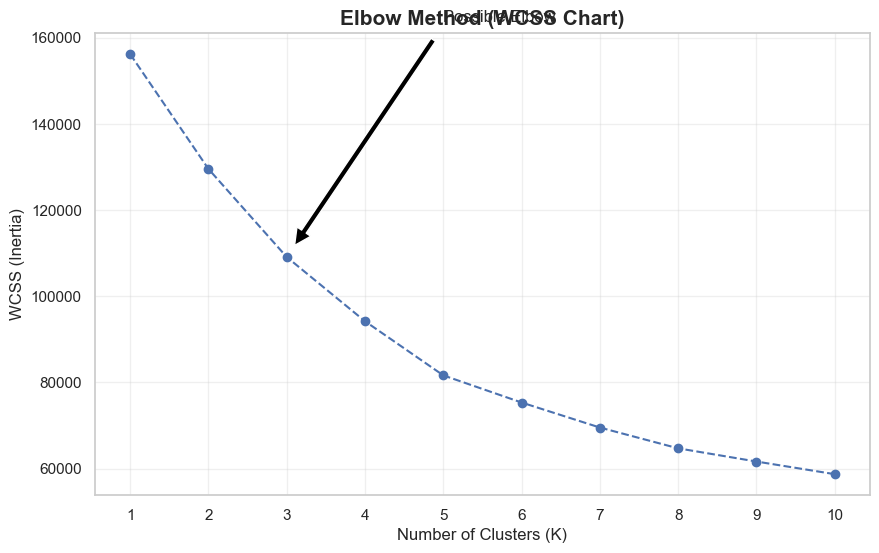

In [20]:
# --- Elbow Method (WCSS) ---
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (WCSS Chart)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)

# Annotate the "Elbow" if you want to be precise
plt.annotate('Possible Elbow', xy=(3, wcss[2]), xytext=(5, wcss[2]*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True, alpha=0.3)
plt.show()


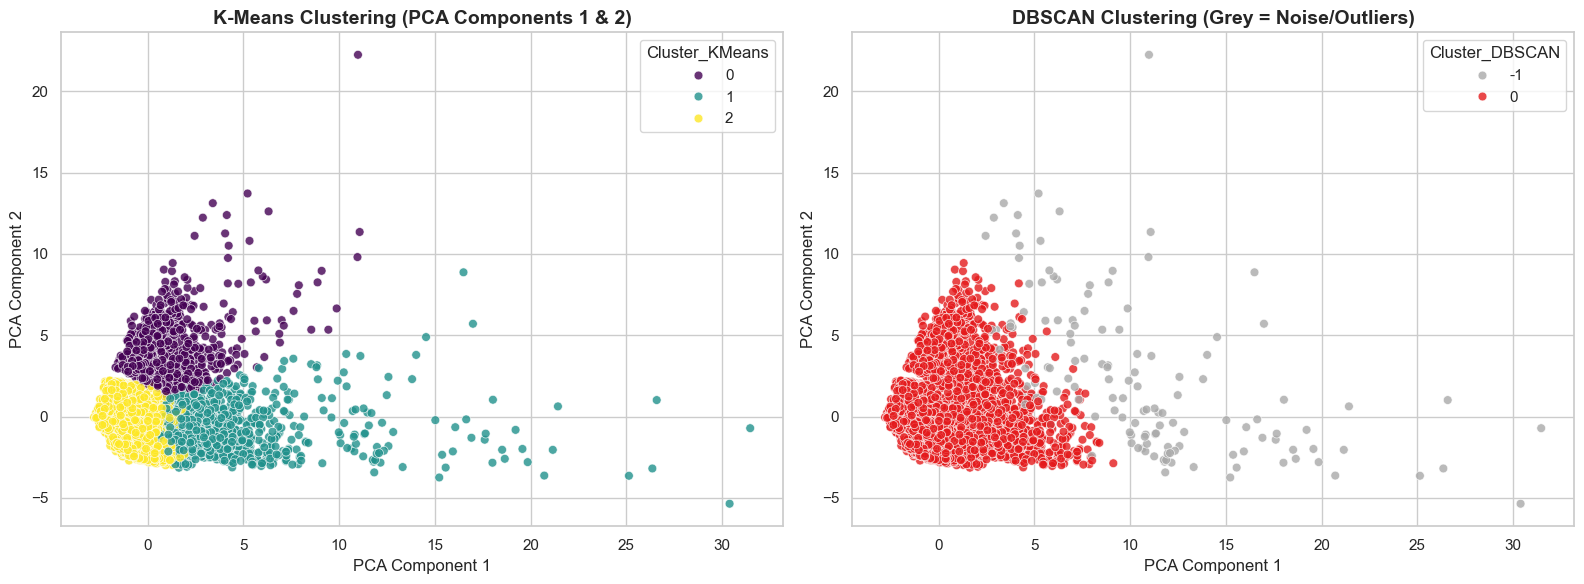

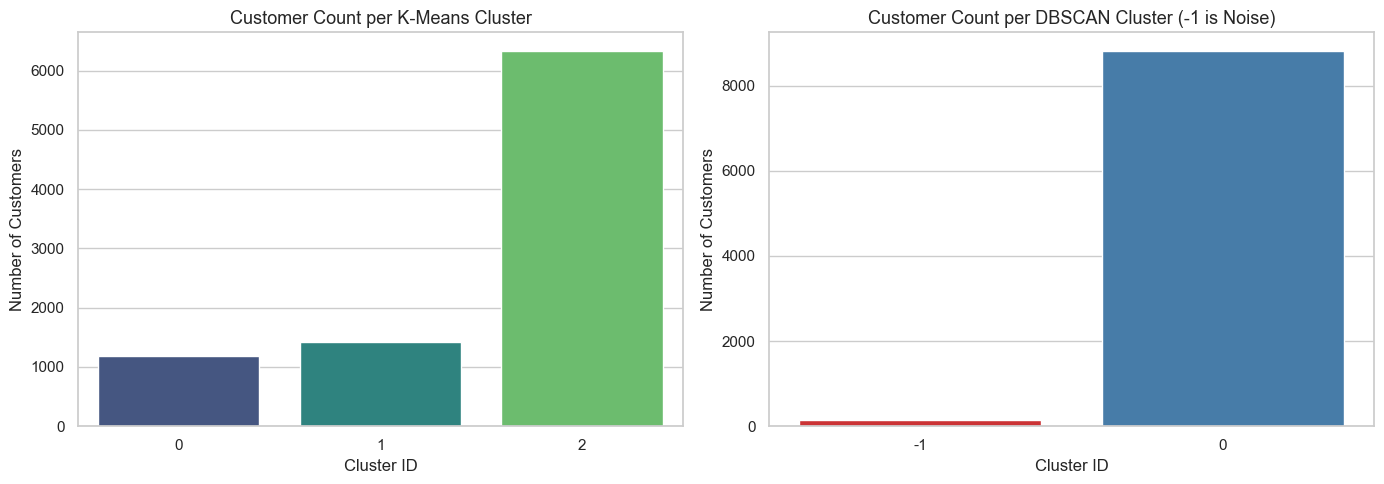

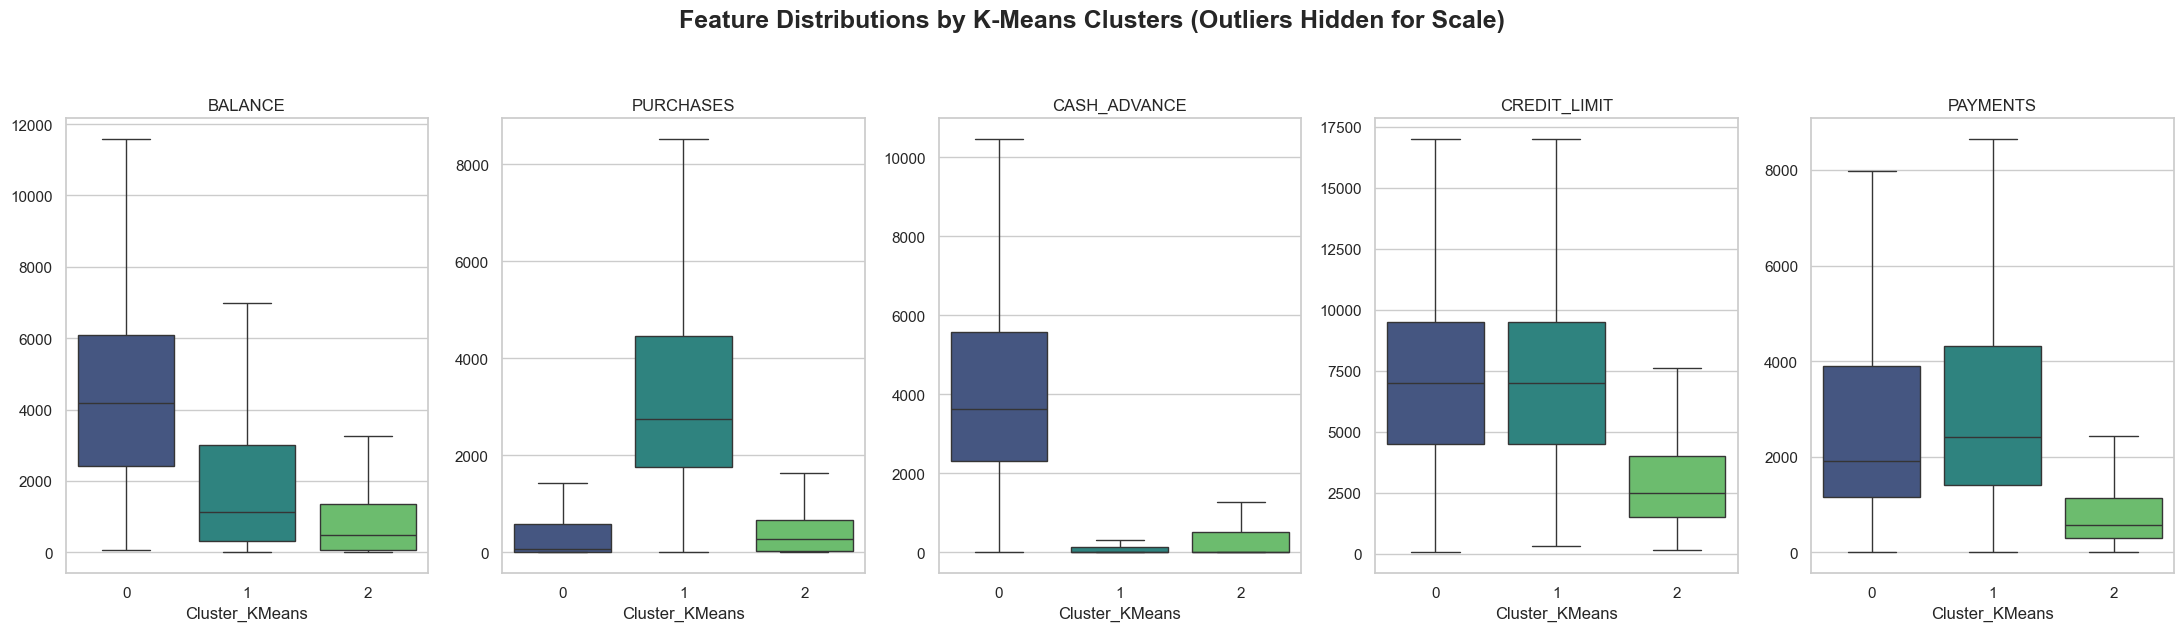

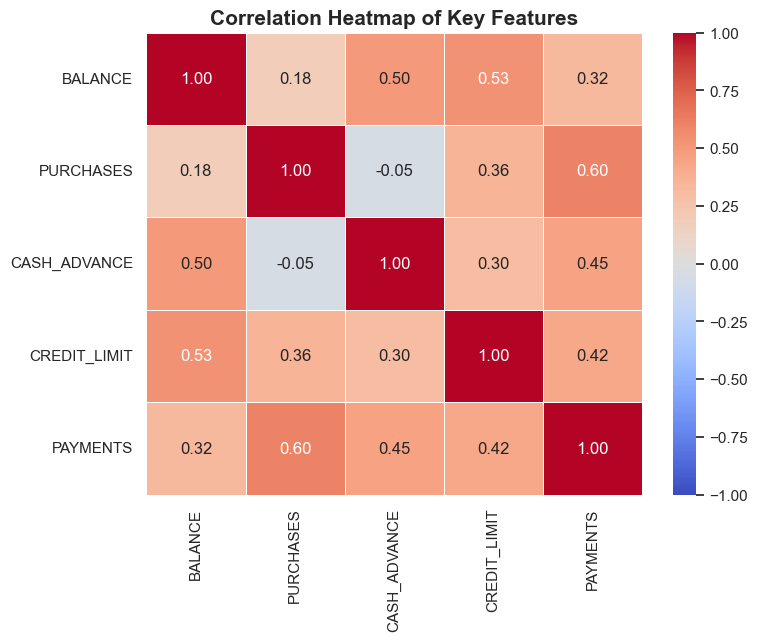

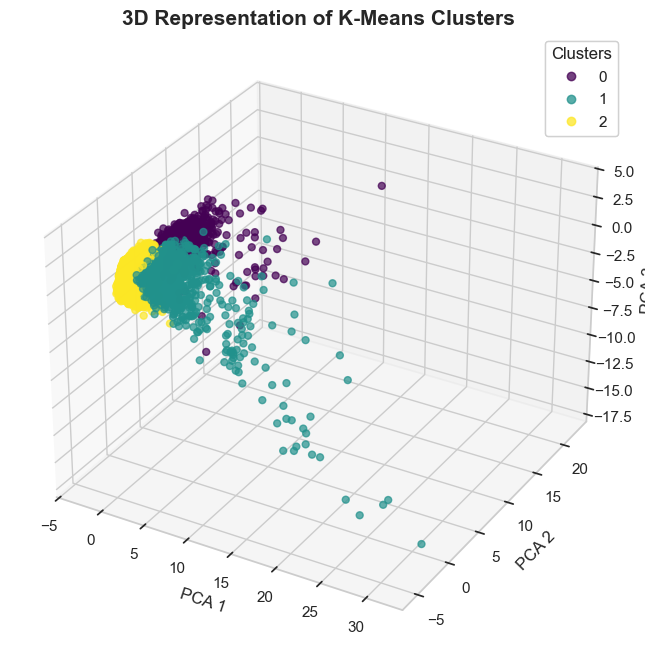

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style using seaborn
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# 1. 2D PCA Scatter Plots (K-Means vs DBSCAN)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster_KMeans'], 
                palette="viridis", ax=axes[0], s=40, alpha=0.8)
axes[0].set_title("K-Means Clustering (PCA Components 1 & 2)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# Plot DBSCAN (Create a palette where Noise (-1) is grey)
n_dbscan_clusters = df['Cluster_DBSCAN'].nunique()
try:
    # Attempt to assign grey to -1, and distinct colors to valid clusters
    db_palette = ['#a9a9a9'] + sns.color_palette("Set1", n_dbscan_clusters - 1).as_hex() 
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster_DBSCAN'], 
                    palette=db_palette, ax=axes[1], s=40, alpha=0.8)
except:
    # Safe fallback if colors don't map perfectly
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster_DBSCAN'], 
                    palette="Set1", ax=axes[1], s=40, alpha=0.8)

axes[1].set_title("DBSCAN Clustering (Grey = Noise/Outliers)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. Cluster Size Distributions (Bar Charts)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Cluster_KMeans', data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Customer Count per K-Means Cluster", fontsize=13)
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("Cluster ID")

sns.countplot(x='Cluster_DBSCAN', data=df, ax=axes[1], palette="Set1")
axes[1].set_title("Customer Count per DBSCAN Cluster (-1 is Noise)", fontsize=13)
axes[1].set_ylabel("Number of Customers")
axes[1].set_xlabel("Cluster ID")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. Feature Profiling (Boxplots) for K-Means
# -------------------------------------------------------------
# Determine which KPIs really drive each cluster
kpi_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(1, len(kpi_features), figsize=(22, 6))
fig.suptitle("Feature Distributions by K-Means Clusters (Outliers Hidden for Scale)", 
             y=1.05, fontsize=18, fontweight='bold')

for i, feature in enumerate(kpi_features):
    # showfliers=False prevents massive outliers from ruining the visual scale of the box
    sns.boxplot(x='Cluster_KMeans', y=feature, data=df, ax=axes[i], palette="viridis", showfliers=False)
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4. Correlation Heatmap of original Key Features
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))
corr = df[kpi_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Key Features", fontsize=15, fontweight='bold')
plt.show()

# -------------------------------------------------------------
# 5. 3D PCA Viewer (Optional, only runs if you kept >= 3 PCA components)
# -------------------------------------------------------------
if X_pca.shape[1] >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                         c=df['Cluster_KMeans'], cmap='viridis', s=25, alpha=0.7)
    
    ax.set_title("3D Representation of K-Means Clusters", fontsize=15, fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')
    
    # Add a legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
    ax.add_artist(legend1)
    
    plt.show()


          PHASE 3: LEAD ANALYSIS TASKS               

--- 1. DBSCAN NOISE ANALYSIS ---
Average Values for Noise (-1) vs Normal Clusters:
              Noise (-1)   Normal
BALANCE          5469.23  1501.97
PURCHASES        9668.81   864.50
CASH_ADVANCE     4760.51   918.34
CREDIT_LIMIT    11775.18  4377.64

Out of 141 total DBSCAN anomalies:
👉 Potential 'Whales' (Ultra-high spend/balance): 62
👉 Potential 'Ghosts' (Inactive/Zero-limit accounts): 0
👉 Mixed/Other Anomalies: 79

--- 2. CENTROID DRIFT (K-MEANS VS DBSCAN) ---
Comparing the center of the largest clusters from both algorithms:
              K-Means (Cluster 2)  DBSCAN (Cluster 0)
BALANCE                    884.36             1501.97
PURCHASES                  469.60              864.50
CASH_ADVANCE               439.28              918.34
CREDIT_LIMIT              3272.29             4377.64

Overlap: 71.8% of the DBSCAN core cluster is contained inside the largest K-Means cluster.

--- 3. FEATURE IMPORTANCE (RANDOM FOREST) --

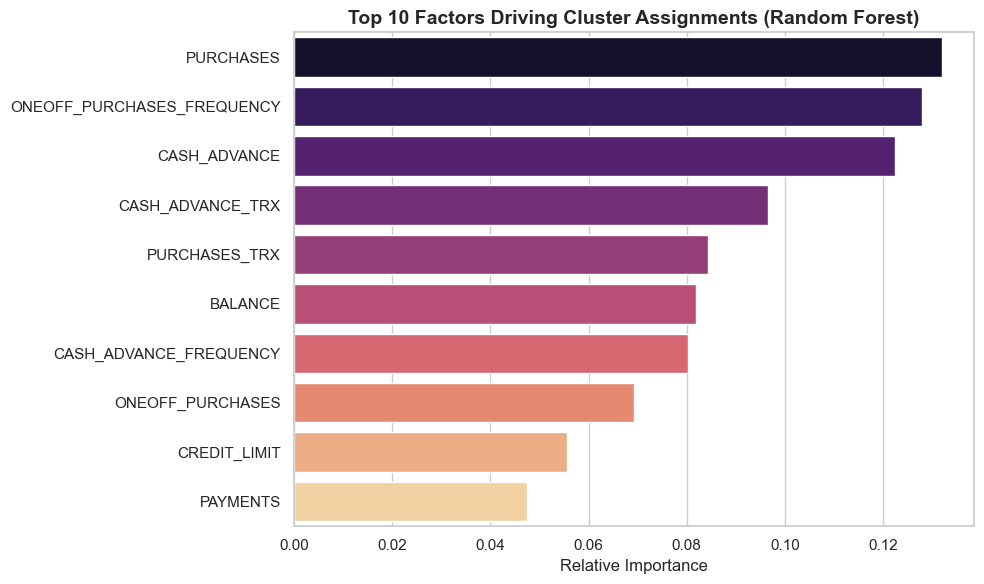

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Define the key features we want to look at for profiling
kpi_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

print("=====================================================")
print("          PHASE 3: LEAD ANALYSIS TASKS               ")
print("=====================================================")

# -------------------------------------------------------------
# TASK 1: The Noise Analysis ("Whales" vs "Ghosts")
# -------------------------------------------------------------
print("\n--- 1. DBSCAN NOISE ANALYSIS ---")
noise_df = df[df['Cluster_DBSCAN'] == -1]
valid_df = df[df['Cluster_DBSCAN'] != -1]

print("Average Values for Noise (-1) vs Normal Clusters:")
comparison = pd.DataFrame({
    'Noise (-1)': noise_df[kpi_features].mean(),
    'Normal': valid_df[kpi_features].mean()
})
print(comparison.round(2))

# Let's categorize the Noise. 
# "Whales" = Top 25% of spenders/balances within the outliers
# "Ghosts" = Extremely low activity (e.g. balance and purchases both under $50)
if len(noise_df) > 0:
    whales = noise_df[(noise_df['PURCHASES'] > noise_df['PURCHASES'].quantile(0.75)) | 
                      (noise_df['BALANCE'] > noise_df['BALANCE'].quantile(0.75))]
    ghosts = noise_df[(noise_df['BALANCE'] < 50) & (noise_df['PURCHASES'] < 50)]
    
    print(f"\nOut of {len(noise_df)} total DBSCAN anomalies:")
    print(f"👉 Potential 'Whales' (Ultra-high spend/balance): {len(whales)}")
    print(f"👉 Potential 'Ghosts' (Inactive/Zero-limit accounts): {len(ghosts)}")
    print(f"👉 Mixed/Other Anomalies: {len(noise_df) - len(whales) - len(ghosts)}")


# -------------------------------------------------------------
# TASK 2: Centroid Drift
# -------------------------------------------------------------
print("\n--- 2. CENTROID DRIFT (K-MEANS VS DBSCAN) ---")
# Let's test if the "Main" cluster in K-Means is the same as the "Main" cluster in DBSCAN
largest_kmeans = df['Cluster_KMeans'].value_counts().idxmax()

if len(valid_df) > 0:
    largest_dbscan = valid_df['Cluster_DBSCAN'].value_counts().idxmax()
    
    kmeans_centroid = df[df['Cluster_KMeans'] == largest_kmeans][kpi_features].mean()
    dbscan_centroid = df[df['Cluster_DBSCAN'] == largest_dbscan][kpi_features].mean()
    
    centroid_comparison = pd.DataFrame({
        f'K-Means (Cluster {largest_kmeans})': kmeans_centroid,
        f'DBSCAN (Cluster {largest_dbscan})': dbscan_centroid
    })
    print("Comparing the center of the largest clusters from both algorithms:")
    print(centroid_comparison.round(2))
    
    overlap = len(df[(df['Cluster_KMeans'] == largest_kmeans) & (df['Cluster_DBSCAN'] == largest_dbscan)])
    percent_overlap = (overlap / len(df[df['Cluster_DBSCAN'] == largest_dbscan])) * 100
    print(f"\nOverlap: {percent_overlap:.1f}% of the DBSCAN core cluster is contained inside the largest K-Means cluster.")
else:
    print("DBSCAN only found noise! Try adjusting your EPS/Min_samples.")


# -------------------------------------------------------------
# TASK 3: Feature Importance (Random Forest)
# -------------------------------------------------------------
print("\n--- 3. FEATURE IMPORTANCE (RANDOM FOREST) ---")

# We train a classifier to predict the K-Means cluster using the original data.
# The features the tree relies on most are the features driving the segmentation.
features_for_rf = [col for col in df.columns if 'Cluster' not in col]
X_rf = df[features_for_rf]
y_rf = df['Cluster_KMeans']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_rf, y_rf)

# Extract importances
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features_for_rf, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("Top 3 most important features driving the K-Means segmentation:")
for i, row in feature_imp_df.head(3).iterrows():
    print(f"⭐ {row['Feature']}: {row['Importance']:.4f}")

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='magma')
plt.title('Top 10 Factors Driving Cluster Assignments (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()
